In [1]:
import seaborn as sns

from utils import load_data

sns.set_style("whitegrid")
sns.set_context("notebook")


In [2]:
#parameters
db = "enamine10k_batch.sqlite"
TITLE = "Enamine10k"

In [3]:
# Parameters
db = "enamine_50k_shuffled.sqlite"
TITLE = "Enamine50k"


In [4]:
data, top_k = load_data(f"results/{db}", k_ratio=0.01)
K = len(top_k)
data.head()

,id,experiment_id,molecule,affinity,prediction_mean,prediction_std,Iteration,cluster,output_file_path,is_validation_result,...,output_file,n_clusters,simulator,bandit_confidence,job_id,Embedding Model,Surrogate,Scoring,is_top_k,is_top_k_cum
0,1,1,Cc1cc[nH]c1C(=O)N1CCN(C)C(c2nc(C3CC3)no2)C1,-6.8,-6.800000,0.166657,0,0,None,0,...,enamine_50k_shuffled,1,None,1.0,0,MolFormer,Linear,Expected Improvement,False,0
1,2,1,Cc1nnc(N(C)CC(C)C(=O)O)s1,-6.2,-6.800000,1.720660,1,0,None,0,...,enamine_50k_shuffled,1,None,1.0,0,MolFormer,Linear,Expected Improvement,False,0
2,3,1,O=C(Cc1cc(C2CC2)no1)N1CCCN(C(=O)Cc2cc(C3CC3)no...,-8.4,-6.827105,0.044814,2,0,None,0,...,enamine_50k_shuffled,1,None,1.0,0,MolFormer,Linear,Expected Improvement,False,0
3,4,1,NC(=O)CC1CCN(C(=O)NCc2nc(C3CC3)no2)CC1,-8.1,-7.603085,0.200014,3,0,None,0,...,enamine_50k_shuffled,1,None,1.0,0,MolFormer,Linear,Expected Improvement,False,0
4,5,1,CCCn1cc(NC(=O)CCc2nc(C3CCCC3)no2)ccc1=O,-8.2,-7.645514,0.114967,4,0,None,0,...,enamine_50k_shuffled,1,None,1.0,0,MolFormer,Linear,Expected Improvement,False,0


In [5]:
HUE_ORDER=sorted(data["Surrogate"].unique())

Text(0.5, 1.0, 'Enamine50k')

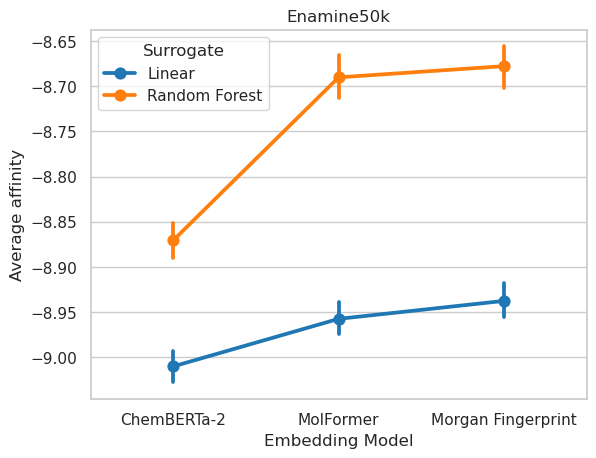

In [6]:
g = sns.pointplot(
    data,
    y="affinity",
    x="Embedding Model",
    hue="Surrogate",
    hue_order=HUE_ORDER,
    order=sorted(data["Embedding Model"].unique())
)
g.set_ylabel("Average affinity")
g.set_title(TITLE)

In [7]:
data.groupby(["Embedding Model", "Surrogate"])["is_top_k"].agg(lambda x: x.sum() / K)

Embedding Model     Surrogate    
ChemBERTa-2         Linear           0.818548
                    Random Forest    0.739919
MolFormer           Linear           0.780242
                    Random Forest    0.582661
Morgan Fingerprint  Linear           0.747984
                    Random Forest    0.518145
Name: is_top_k, dtype: float64

Text(0.5, 1.0, 'Enamine50k')

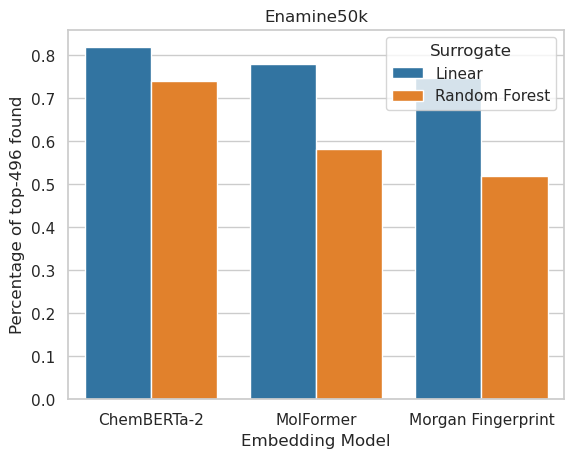

In [8]:
g = sns.barplot(
    data,
    y="is_top_k",
    x="Embedding Model",
    hue="Surrogate",
    hue_order=HUE_ORDER,
    errorbar=None,
    estimator = lambda x: x.sum() / K,
    order=sorted(data["Embedding Model"].unique()),
    dodge=True
)
g.set_ylabel(f"Percentage of top-{K} found")
g.set_title(TITLE)

Text(0.5, 0.98, 'Enamine50k')

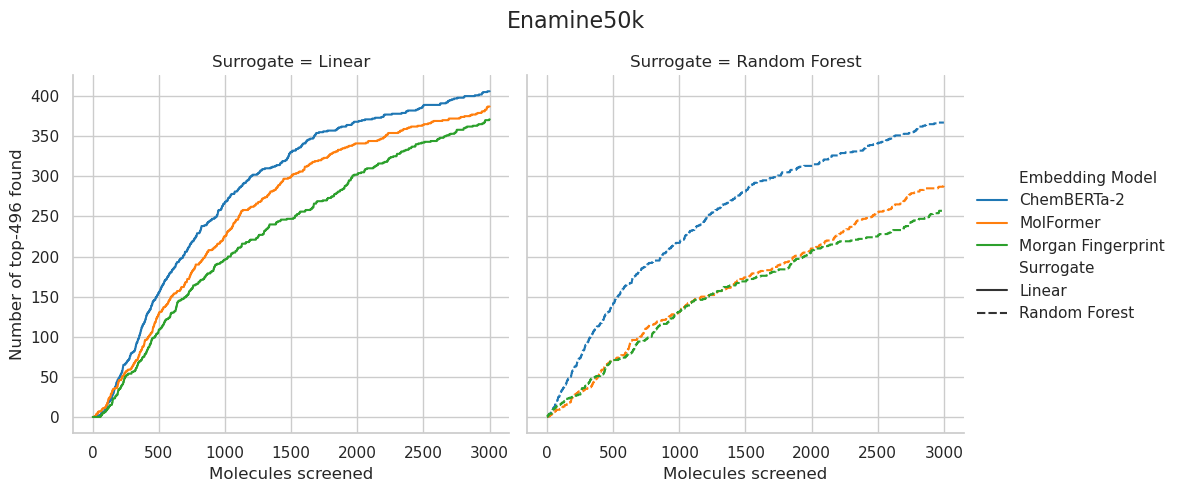

In [9]:
import matplotlib.pyplot as plt

use_markers = data["Iteration"].max() < 10

g = sns.relplot(
    data,
    y="is_top_k_cum",
    x="Iteration",
    hue="Embedding Model",
    col="Surrogate",
    col_order=["Linear", "Random Forest"],
    errorbar=None,
    kind="line",
    style="Surrogate",
    style_order=["Linear", "Random Forest"],
    markers="o" if use_markers else None,
    markeredgecolor="k",
    hue_order=sorted(data["Embedding Model"].unique())
)


g.set_xlabels("Molecules screened")
g.set_ylabels(f"Number of top-{K} found")
if use_markers:
    labels = [0] + sorted(data["Iteration"].unique() * len(top_k))
    def set_ticks(**kwargs):
        plt.gca().set_xticklabels(labels)

    g.map(set_ticks)
g.figure.subplots_adjust(top=0.85)
g.figure.suptitle(TITLE, fontsize=16)
